# SpaceTimePy test performance

This notebook compares pytest runs without SpaceTimePy and with SpaceTimePy profile capture. It measures elapsed time and test outcomes for each repository.

The notebook reads `results/raw/*_wtm` as baseline runs. It reads `results/raw/*_wm_wf` as SpaceTimePy runs. It does not use the optional `*_wm_wtf` run because this run is not available for each repository.

## Method

The parser reads the final pytest summary in each text file. It extracts the elapsed time and each reported outcome count. It also reads the collected test count.

An interrupted run is not equivalent to a complete run. The tables and charts mark these runs. The summary excludes them from the aggregate comparison.

In [81]:
from collections import Counter
from dataclasses import asdict
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import spacetimepy
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "Select the project .venv Python kernel. SpaceTimePy is not available in the current kernel."
    ) from error

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

RAW_DIR_CANDIDATES = [
    Path.cwd() / "results" / "raw",
    Path.cwd().parent / "results" / "raw",
]
RAW_DIR = next((path for path in RAW_DIR_CANDIDATES if path.is_dir()), None)
if RAW_DIR is None:
    raise FileNotFoundError("Cannot find the results/raw directory.")

RUN_SUFFIXES = {
    "Without SpaceTimePy": "_wtm",
    "With SpaceTimePy": "_wm_wf",
}
OUTCOMES = ("passed", "failed", "skipped", "xfailed", "xpassed", "error", "errors", "warnings")
SUMMARY_RE = re.compile(
    rf"(?P<body>(?:\d+\s+(?:{'|'.join(OUTCOMES)})(?:,\s*)?)+)\s+in\s+"
    r"(?P<seconds>\d+(?:\.\d+)?)s"
)
COUNT_RE = re.compile(rf"(\d+)\s+({'|'.join(OUTCOMES)})")
COLLECTED_RE = re.compile(r"collected\s+(\d+)\s+items?")
INTERRUPTED_RE = re.compile(r"^!+\s+KeyboardInterrupt\s+!+$", re.MULTILINE)

In [82]:
def parse_pytest_result(path, repository, condition):
    text = path.read_text(encoding="utf-8", errors="replace")
    summaries = list(SUMMARY_RE.finditer(text))
    summary = summaries[-1] if summaries else None
    counts = {outcome: 0 for outcome in OUTCOMES}

    if summary is not None:
        for value, outcome in COUNT_RE.findall(summary.group("body")):
            counts[outcome] = int(value)

    collected_match = COLLECTED_RE.search(text)
    interrupted = bool(INTERRUPTED_RE.search(text))
    if interrupted:
        status = "interrupted"
    elif summary is not None:
        status = "complete"
    else:
        status = "unknown"

    return {
        "repository": repository,
        "condition": condition,
        "file": str(path),
        "status": status,
        "collected": int(collected_match.group(1)) if collected_match else np.nan,
        "elapsed_seconds": float(summary.group("seconds")) if summary else np.nan,
        "passed": counts["passed"],
        "failed": counts["failed"],
        "skipped": counts["skipped"],
        "xfailed": counts["xfailed"],
        "xpassed": counts["xpassed"],
        "errors": counts["error"] + counts["errors"],
        "warnings": counts["warnings"],
    }


records = []
for condition, suffix in RUN_SUFFIXES.items():
    for path in sorted(RAW_DIR.glob(f"*{suffix}")):
        repository = path.name.removesuffix(suffix)
        records.append(parse_pytest_result(path, repository, condition))

runs = pd.DataFrame(records).sort_values(["repository", "condition"]).reset_index(drop=True)
if runs.empty:
    raise ValueError(f"No benchmark text files exist in {RAW_DIR}.")
if runs.duplicated(["repository", "condition"]).any():
    raise ValueError("A repository has more than one file for a condition.")

display(
    runs[["repository", "condition", "status", "collected", "passed", "failed", "elapsed_seconds"]]
    .style.format({"collected": "{:.0f}", "elapsed_seconds": "{:.2f}"}, na_rep="missing")
)

,repository,condition,status,collected,passed,failed,elapsed_seconds
0,beets,With SpaceTimePy,complete,2866,2733,0,90.75
1,beets,Without SpaceTimePy,complete,2866,2733,0,58.52
2,cherrypy,With SpaceTimePy,complete,300,289,1,146.78
3,cherrypy,Without SpaceTimePy,complete,300,289,1,129.43
4,discordpy,With SpaceTimePy,complete,294,294,0,6.28
5,discordpy,Without SpaceTimePy,complete,294,294,0,2.91
6,dspy,With SpaceTimePy,complete,1715,1263,0,122.16
7,dspy,Without SpaceTimePy,complete,1715,1263,0,109.11
8,pymisp,With SpaceTimePy,complete,121,118,1,153.82
9,pymisp,Without SpaceTimePy,complete,121,118,1,118.91


## Comparison table

The time factor is `with time / without time`. A value greater than 1 means that the SpaceTimePy run took more time.

In [83]:
baseline = (
    runs[runs["condition"] == "Without SpaceTimePy"]
    .set_index("repository")
    .add_suffix("_without")
)
with_spacetime = (
    runs[runs["condition"] == "With SpaceTimePy"]
    .set_index("repository")
    .add_suffix("_with")
)
comparison = baseline.join(with_spacetime, how="outer")
comparison["time_delta_seconds"] = comparison["elapsed_seconds_with"] - comparison["elapsed_seconds_without"]
comparison["time_factor"] = comparison["elapsed_seconds_with"] / comparison["elapsed_seconds_without"]
comparison["overhead_percent"] = (comparison["time_factor"] - 1) * 100
comparison["passed_delta"] = comparison["passed_with"] - comparison["passed_without"]
comparison["complete_pair"] = (
    comparison["status_without"].eq("complete")
    & comparison["status_with"].eq("complete")
)

comparison_columns = [
    "elapsed_seconds_without",
    "elapsed_seconds_with",
    "time_delta_seconds",
    "time_factor",
    "overhead_percent",
    "passed_without",
    "passed_with",
    "passed_delta",
    "failed_without",
    "failed_with",
    "status_without",
    "status_with",
    "complete_pair",
]
display(
    comparison[comparison_columns].style.format(
        {
            "elapsed_seconds_without": "{:.2f}",
            "elapsed_seconds_with": "{:.2f}",
            "time_delta_seconds": "{:+.2f}",
            "time_factor": "{:.2f}×",
            "overhead_percent": "{:+.1f}%",
            "passed_delta": "{:+.0f}",
        },
        na_rep="missing",
    )
)

,elapsed_seconds_without,elapsed_seconds_with,time_delta_seconds,time_factor,overhead_percent,passed_without,passed_with,passed_delta,failed_without,failed_with,status_without,status_with,complete_pair
repository,,,,,,,,,,,,,
beets,58.52,90.75,+32.23,1.55×,+55.1%,2733,2733,+0,0,0,complete,complete,True
cherrypy,129.43,146.78,+17.35,1.13×,+13.4%,289,289,+0,1,1,complete,complete,True
discordpy,2.91,6.28,+3.37,2.16×,+115.8%,294,294,+0,0,0,complete,complete,True
dspy,109.11,122.16,+13.05,1.12×,+12.0%,1263,1263,+0,0,0,complete,complete,True
pymisp,118.91,153.82,+34.91,1.29×,+29.4%,118,118,+0,1,1,complete,complete,True


## Elapsed time and passed tests

The time chart uses a logarithmic scale because the repositories have substantially different run times. Red hatching identifies an interrupted run.

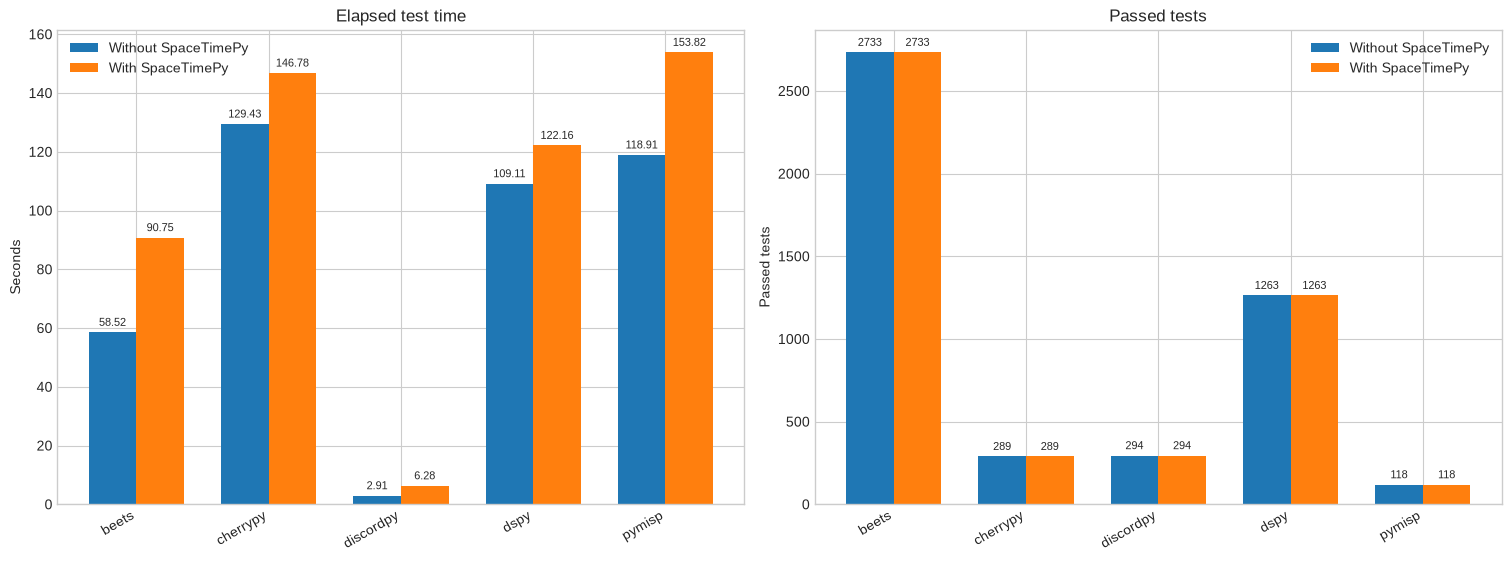

In [84]:
plot_data = comparison.sort_index()
repositories = plot_data.index.tolist()
positions = np.arange(len(repositories))
width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

time_without = axes[0].bar(
    positions - width / 2, plot_data["elapsed_seconds_without"], width, label="Without SpaceTimePy"
)
time_with = axes[0].bar(
    positions + width / 2, plot_data["elapsed_seconds_with"], width, label="With SpaceTimePy"
)
axes[0].set_title("Elapsed test time")
axes[0].set_ylabel("Seconds")
#axes[0].set_yscale("log")
axes[0].set_xticks(positions, repositories, rotation=30, ha="right")
axes[0].bar_label(time_without, fmt="%.2f", padding=3, fontsize=8)
axes[0].bar_label(time_with, fmt="%.2f", padding=3, fontsize=8)
axes[0].legend()

passed_without = axes[1].bar(
    positions - width / 2, plot_data["passed_without"], width, label="Without SpaceTimePy"
)
passed_with = axes[1].bar(
    positions + width / 2, plot_data["passed_with"], width, label="With SpaceTimePy"
)
axes[1].set_title("Passed tests")
axes[1].set_ylabel("Passed tests")
axes[1].set_xticks(positions, repositories, rotation=30, ha="right")
axes[1].bar_label(passed_without, fmt="%.0f", padding=3, fontsize=8)
axes[1].bar_label(passed_with, fmt="%.0f", padding=3, fontsize=8)
axes[1].legend()

for index, (_, row) in enumerate(plot_data.iterrows()):
    if row["status_with"] != "complete":
        for bar in (time_with[index], passed_with[index]):
            bar.set_hatch("///")
            bar.set_edgecolor("crimson")
            bar.set_linewidth(1.5)

plt.show()

# SpaceTimePy monitoring data

This section uses `spacetimepy.TraceData.open()` to read each `*_db_prof.db` database. It does not use direct SQL queries.

An object identity represents one captured Python object. A stored value represents one captured version of an object. One object identity can have multiple stored values.

A serialization problem is one persisted `SerializationError` entry in a function call or stack snapshot. Repeated failures for the same variable count as separate occurrences.

In [85]:
DATABASE_SUFFIX = "_db_prof.db"
SERIALIZATION_TYPE_RE = re.compile(r"value of type (?P<type_name>.+)$")


def read_capture_problems(repository, source_kind, items):
    problems = []
    for item in items:
        capture_errors = item.attributes.get("capture_errors", {})
        for value_name, message in capture_errors.items():
            message = str(message)
            type_match = SERIALIZATION_TYPE_RE.search(message)
            problems.append(
                {
                    "repository": repository,
                    "source_kind": source_kind,
                    "source_id": item.id,
                    "value_name": value_name,
                    "message": message,
                    "is_serialization_problem": message.startswith("SerializationError:"),
                    "type_name": type_match.group("type_name") if type_match else "not reported",
                }
            )
    return problems


def summarize_trace(path):
    repository = path.name.removesuffix(DATABASE_SUFFIX)
    with spacetimepy.TraceData.open(path) as trace:
        statistics = asdict(trace.get_statistics())
        sessions = trace.list_sessions()
        calls = trace.list_function_calls()
        snapshots = trace.list_stack_snapshots()
        performances = trace.list_function_call_performances()

    problems = read_capture_problems(repository, "function call", calls)
    problems.extend(read_capture_problems(repository, "stack snapshot", snapshots))
    serialization_problems = [problem for problem in problems if problem["is_serialization_problem"]]
    affected_records = {
        (problem["source_kind"], problem["source_id"])
        for problem in serialization_problems
    }
    direct_capture_ns = np.array([item.direct_capture_ns for item in performances], dtype=np.int64)
    session_statuses = Counter(session.status for session in sessions)

    row = {
        "repository": repository,
        "database_megabytes": path.stat().st_size / 1024**2,
        "session_statuses": ", ".join(f"{status}: {count}" for status, count in sorted(session_statuses.items())) or "none",
        **statistics,
        "returned_call_count": sum(call.outcome == "returned" for call in calls),
        "raised_call_count": sum(call.outcome == "raised" for call in calls),
        "running_call_count": sum(call.outcome == "running" for call in calls),
        "capture_problem_occurrences": len(problems),
        "serialization_problem_occurrences": len(serialization_problems),
        "records_with_serialization_problems": len(affected_records),
        "serialization_problem_type_count": len({problem["type_name"] for problem in serialization_problems}),
        "direct_capture_seconds": direct_capture_ns.sum() / 1_000_000_000 if direct_capture_ns.size else 0.0,
        "mean_direct_capture_ms": direct_capture_ns.mean() / 1_000_000 if direct_capture_ns.size else np.nan,
        "p95_direct_capture_ms": np.percentile(direct_capture_ns, 95) / 1_000_000 if direct_capture_ns.size else np.nan,
        "maximum_direct_capture_ms": direct_capture_ns.max() / 1_000_000 if direct_capture_ns.size else np.nan,
        "line_event_count": sum(item.line_event_count for item in performances),
        "line_snapshot_count": sum(item.line_snapshot_count for item in performances),
        "filtered_line_event_count": sum(item.filtered_line_event_count for item in performances),
    }
    return row, problems

In [86]:
monitoring_rows = []
capture_problem_rows = []
for database_path in sorted(RAW_DIR.glob(f"*{DATABASE_SUFFIX}")):
    monitoring_row, database_problems = summarize_trace(database_path)
    monitoring_rows.append(monitoring_row)
    capture_problem_rows.extend(database_problems)

monitoring = pd.DataFrame(monitoring_rows).set_index("repository").sort_index()
capture_problems = pd.DataFrame(capture_problem_rows)
#serialization_problems = capture_problems[capture_problems["is_serialization_problem"]].copy()
monitoring["pytest_elapsed_seconds"] = comparison["elapsed_seconds_with"]
monitoring["direct_capture_share_percent"] = (
    monitoring["direct_capture_seconds"] / monitoring["pytest_elapsed_seconds"] * 100
)

monitoring_columns = [
    "database_megabytes",
    "session_statuses",
    "session_count",
    "step_count",
    "function_call_count",
    "stack_snapshot_count",
    "external_interaction_count",
    "object_identity_count",
    "stored_value_count",
    "serialization_problem_occurrences",
    "records_with_serialization_problems",
    "serialization_problem_type_count",
    "raised_call_count",
    "function_call_capture_performance_count",
    "direct_capture_seconds",
    "direct_capture_share_percent",
    "mean_direct_capture_ms",
    "p95_direct_capture_ms",
    "line_event_count",
    "filtered_line_event_count",
]
display(
    monitoring[monitoring_columns].style.format(
        {
            "database_megabytes": "{:.2f}",
            "direct_capture_seconds": "{:.2f}",
            "direct_capture_share_percent": "{:.1f}%",
            "mean_direct_capture_ms": "{:.2f}",
            "p95_direct_capture_ms": "{:.2f}",
        },
        na_rep="not available",
    )
)

,database_megabytes,session_statuses,session_count,step_count,function_call_count,stack_snapshot_count,external_interaction_count,object_identity_count,stored_value_count,serialization_problem_occurrences,records_with_serialization_problems,serialization_problem_type_count,raised_call_count,function_call_capture_performance_count,direct_capture_seconds,direct_capture_share_percent,mean_direct_capture_ms,p95_direct_capture_ms,line_event_count,filtered_line_event_count
repository,,,,,,,,,,,,,,,,,,,,
beets,186.19,completed: 1,1,2791,2791,19721,0,8173,12233,0,0,0,23,2791,33.06,36.4%,11.85,37.87,19721,0
cherrypy,71.91,completed: 1,1,222,222,4669,0,829,1498,0,0,0,3,222,5.43,3.7%,24.44,86.65,4669,0
discordpy,4.56,completed: 1,1,294,294,3022,0,874,1182,0,0,0,0,294,3.55,56.6%,12.09,44.28,3022,0
dspy,36.43,completed: 1,1,1265,1286,19315,21,3851,4995,0,0,0,2,1286,16.35,13.4%,12.71,42.91,19315,0
pymisp,36.44,completed: 1,1,119,119,24919,0,11060,12257,0,0,0,1,119,20.51,13.3%,172.34,106.03,24919,0


## Captured entities and serialization problems

The first chart separates object identities from stored object versions. The second chart compares function calls with stack snapshots.

The third chart shows serialization-problem occurrences and affected capture records. One record can contain more than one problem.

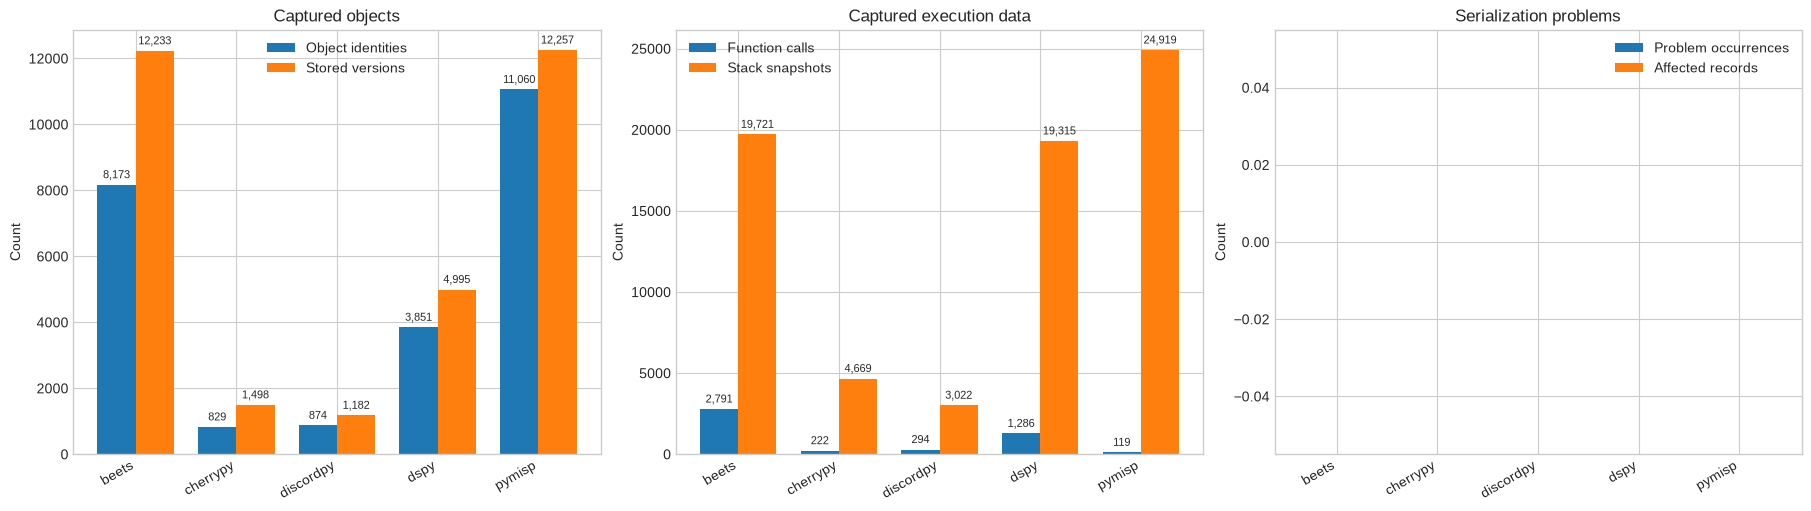

In [87]:
repositories = monitoring.index.tolist()
positions = np.arange(len(repositories))
width = 0.38
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

object_bars = [
    axes[0].bar(positions - width / 2, monitoring["object_identity_count"], width, label="Object identities"),
    axes[0].bar(positions + width / 2, monitoring["stored_value_count"], width, label="Stored versions"),
]
axes[0].set_title("Captured objects")
axes[0].set_ylabel("Count")
axes[0].legend()

event_bars = [
    axes[1].bar(positions - width / 2, monitoring["function_call_count"], width, label="Function calls"),
    axes[1].bar(positions + width / 2, monitoring["stack_snapshot_count"], width, label="Stack snapshots"),
]
axes[1].set_title("Captured execution data")
axes[1].set_ylabel("Count")
axes[1].legend()

problem_bars = [
    axes[2].bar(positions - width / 2, monitoring["serialization_problem_occurrences"], width, label="Problem occurrences"),
    axes[2].bar(positions + width / 2, monitoring["records_with_serialization_problems"], width, label="Affected records"),
]
axes[2].set_title("Serialization problems")
axes[2].set_ylabel("Count")
axes[2].legend()

for axis in axes:
    axis.set_xticks(positions, repositories, rotation=30, ha="right")
for bar_groups in (object_bars, event_bars, problem_bars):
    for bars in bar_groups:
        for bar in bars:
            height = bar.get_height()
            if height:
                bar.axes.annotate(
                    f"{height:,.0f}",
                    (bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
plt.show()

## Most frequent serialization problems

The table shows at most eight value types for each repository. The occurrence count includes repeated failures.

In [88]:
if serialization_problems.empty:
    display(Markdown("No serialization problems are present in these databases."))
else:
    serialization_by_type = (
        serialization_problems.groupby(["repository", "type_name"])
        .size()
        .rename("occurrences")
        .reset_index()
        .sort_values(["repository", "occurrences", "type_name"], ascending=[True, False, True])
    )
    top_serialization_types = serialization_by_type.groupby("repository").head(8)
    display(top_serialization_types.set_index(["repository", "type_name"]))

occurrences
repository type_name                                                 
beets      builtins.dict                                          277
           test.test_importer.TestImport                          154
           test.ui.test_ui_importer.TestImport                    154
           test.test_plugins.TestPromptChoices                     51
           _pytest.monkeypatch.MonkeyPatch                         42
           test.plugins.test_fetchart.TestFetchartImport           23
           test.plugins.test_web.TestWebXSS                        21
           builtins.tuple                                          10

## Type report for one database

Set `SELECTED_DATABASE` to one filename from `results/raw`. The report lists each observed type in that database.

A type can have successful captures and serialization problems. This result means that different values of the same type had different outcomes.

The report does not test types that do not occur in the trace.

In [89]:
SELECTED_DATABASE = "beets_db_prof.db"

available_databases = sorted(path.name for path in RAW_DIR.glob(f"*{DATABASE_SUFFIX}"))
if SELECTED_DATABASE not in available_databases:
    choices = ", ".join(available_databases)
    raise ValueError(f"Unknown database {SELECTED_DATABASE!r}. Select one of: {choices}")

selected_path = RAW_DIR / SELECTED_DATABASE
selected_repository = selected_path.name.removesuffix(DATABASE_SUFFIX)
with spacetimepy.TraceData.open(selected_path) as selected_trace:
    selected_values = selected_trace.list_stored_values()
    selected_calls = selected_trace.list_function_calls()
    selected_snapshots = selected_trace.list_stack_snapshots()

selected_problem_rows = read_capture_problems(selected_repository, "function call", selected_calls)
selected_problem_rows.extend(
    read_capture_problems(selected_repository, "stack snapshot", selected_snapshots)
)
selected_serialization_problems = pd.DataFrame(
    [problem for problem in selected_problem_rows if problem["is_serialization_problem"]],
    columns=[
        "repository", "source_kind", "source_id", "value_name",
        "message", "is_serialization_problem", "type_name",
    ],
)
selected_stored_values = pd.DataFrame(
    [
        {
            "type_name": value.type_name,
            "identity_id": value.identity_id,
            "reference": value.reference,
        }
        for value in selected_values
    ],
    columns=["type_name", "identity_id", "reference"],
)

In [90]:
successful_by_type = (
    selected_stored_values.groupby("type_name")
    .agg(
        successful_identity_count=("identity_id", "nunique"),
        successful_version_count=("reference", "nunique"),
    )
)

if selected_serialization_problems.empty:
    problems_by_type = pd.DataFrame(
        columns=["serialization_problem_occurrences", "affected_record_count", "affected_value_name_count"]
    )
else:
    selected_serialization_problems["record_key"] = (
        selected_serialization_problems["source_kind"].astype(str)
        + ":"
        + selected_serialization_problems["source_id"].astype(str)
    )
    problems_by_type = (
        selected_serialization_problems.groupby("type_name")
        .agg(
            serialization_problem_occurrences=("message", "size"),
            affected_record_count=("record_key", "nunique"),
            affected_value_name_count=("value_name", "nunique"),
        )
    )

selected_type_report = successful_by_type.join(problems_by_type, how="outer").fillna(0)
count_columns = [
    "successful_identity_count",
    "successful_version_count",
    "serialization_problem_occurrences",
    "affected_record_count",
    "affected_value_name_count",
]
selected_type_report[count_columns] = selected_type_report[count_columns].astype(int)
selected_type_report["has_successful_capture"] = selected_type_report["successful_version_count"] > 0
selected_type_report["has_serialization_problem"] = (
    selected_type_report["serialization_problem_occurrences"] > 0
)
selected_type_report["observed_status"] = np.select(
    [
        selected_type_report["has_successful_capture"] & selected_type_report["has_serialization_problem"],
        selected_type_report["has_serialization_problem"],
    ],
    ["captured and problematic", "problem only"],
    default="captured without problem",
)
status_order = {"problem only": 0, "captured and problematic": 1, "captured without problem": 2}
selected_type_report["status_order"] = selected_type_report["observed_status"].map(status_order)
selected_type_report = selected_type_report.sort_values(
    ["status_order", "serialization_problem_occurrences", "successful_version_count"],
    ascending=[True, False, False],
).drop(columns="status_order")

display(Markdown(f"### `{SELECTED_DATABASE}`"))
display(selected_type_report)

### `beets_db_prof.db`

,successful_identity_count,successful_version_count,serialization_problem_occurrences,affected_record_count,affected_value_name_count,has_successful_capture,has_serialization_problem,observed_status
type_name,,,,,,,,
beets.library.models.Item,776,1634,0,0,0,True,False,captured without problem
builtins.str,1246,1246,0,0,0,True,False,captured without problem
builtins.list,940,1075,0,0,0,True,False,captured without problem
builtins.dict,804,853,0,0,0,True,False,captured without problem
builtins.tuple,434,633,0,0,0,True,False,captured without problem
...,...,...,...,...,...,...,...,...
test.test_library.TestItemReadGenre,1,1,0,0,0,True,False,captured without problem
test.test_library.TestUnicodePath,1,1,0,0,0,True,False,captured without problem
test.test_plugins.TestDeprecationCopy,1,1,0,0,0,True,False,captured without problem


In [91]:
x = (selected_type_report["has_serialization_problem"] == True)
list(dict(x[x]).keys())

[]

## Monitoring summary

In [92]:
summary_lines = [
    f"- SpaceTimePy opened {len(monitoring)} profiling databases.",
    f"- The databases contain {monitoring['object_identity_count'].sum():,.0f} object identities.",
    f"- The databases contain {monitoring['stored_value_count'].sum():,.0f} stored object versions.",
    f"- The databases contain {monitoring['serialization_problem_occurrences'].sum():,.0f} serialization-problem occurrences.",
]
nonempty = monitoring[monitoring["session_count"] > 0]
empty = monitoring[monitoring["session_count"] == 0]
if not nonempty.empty:
    most_objects = nonempty["stored_value_count"].idxmax()
    most_problems = nonempty["serialization_problem_occurrences"].idxmax()
    summary_lines.append(f"- {most_objects} has the most stored object versions.")
    summary_lines.append(f"- {most_problems} has the most serialization-problem occurrences.")
for repository in empty.index:
    summary_lines.append(f"- {repository} has an empty profiling database. Its interrupted run did not commit trace data.")
summary_lines.append("- Direct capture time measures recorder work. It does not include profiler bookkeeping or database-row persistence.")
display(Markdown("\n".join(summary_lines)))

- SpaceTimePy opened 5 profiling databases.
- The databases contain 24,787 object identities.
- The databases contain 32,165 stored object versions.
- The databases contain 0 serialization-problem occurrences.
- pymisp has the most stored object versions.
- beets has the most serialization-problem occurrences.
- Direct capture time measures recorder work. It does not include profiler bookkeeping or database-row persistence.